# FOMO Object Detection for ESP32-CAM

**Faster Objects, More Objects (FOMO)** — a lightweight centroid-based object detector
designed for microcontrollers.

## Architecture Overview

Unlike traditional detectors (YOLO, SSD) that predict bounding boxes, FOMO:
1. Divides the image into a grid (e.g., 12×12 for 96×96 input)
2. Each grid cell predicts **which class** is centered there (or background)
3. No bounding box regression → drastically fewer parameters
4. Uses a truncated MobileNetV2 backbone (stride-8) for features

This makes it ideal for ESP32-CAM with ~4MB PSRAM and ~520KB SRAM.

### Target Classes
| Index | Class | COCO ID | Purpose |
|-------|-------|---------|----------|
| 0 | background | — | No object |
| 1 | person | 1 | Interaction target |
| 2 | sports_ball | 37 | Fetch/track target |
| 3 | chair | 62 | Obstacle avoidance |
| 4 | couch | 63 | Obstacle avoidance |
| 5 | dining_table | 67 | Obstacle avoidance |

### Memory Budget
- **Model size target**: < 250 KB (int8 quantized TFLite)
- **Input tensor**: 96×96×3 = 27,648 bytes
- **Output tensor**: 12×12×6 = 864 bytes
- **Arena (TFLite Micro)**: ~300 KB (fits in PSRAM)

## 1. Environment Setup

In [1]:
import os
import json
import math
import random
from pathlib import Path
from collections import defaultdict
import pandas as pd
import time

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import cv2

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision.models import mobilenet_v2, MobileNet_V2_Weights

import albumentations as A
from albumentations.pytorch import ToTensorV2
from pycocotools.coco import COCO

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')

Using device: cuda


## 2. Configuration

In [29]:
# ── Model / training config ──────────────────────────────────────────────
INPUT_SIZE     = 96        #
GRID_SIZE      = INPUT_SIZE // 8
CELL_SIZE      = INPUT_SIZE // GRID_SIZE
LEARNING_RATE  = 1e-3
NUM_EPOCHS     = 30
WEIGHT_DECAY   = 1e-4
MNV2_WIDTH_MULT     = 0.25   # MobileNetV2 width multiplier
MNV2_ROUND_NEAREST = 8      # MobileNetV2 round channels to nearest
CONF_THRESHOLD = 0.3

DATASET = "coco"
ENVIRONMENT = "local,gpu"

if "colab" in ENVIRONMENT:
    COCO_ROOT = Path(f'/content/{DATASET}')
    NUM_WORKERS = 2
    BATCH_SIZE = 128
    PIN_MEMORY = True
if "local" in ENVIRONMENT:
    COCO_ROOT = Path.home() / Path(f'datasets/{DATASET}')
    NUM_WORKERS = 4
    BATCH_SIZE = 64
    PIN_MEMORY = False
if "gpu" in ENVIRONMENT:
    NUM_WORKERS = 4
    BATCH_SIZE = 64
    PIN_MEMORY = True
    LEARNING_RATE = 5e-3
    torch.set_float32_matmul_precision('high')
if "macos" in ENVIRONMENT:
    NUM_WORKERS = 0
if "gray" in DATASET:
    IS_GRAYSCALE = True
    INPUT_CHANNELS = 1
else:
    IS_GRAYSCALE = False
    INPUT_CHANNELS = 3

# ── COCO class mapping ───────────────────────────────────────────────────
# Define only your TARGET object classes (COCO_ID: "Name")
# The background class (index 0) will be handled automatically.
TARGET_OBJECTS = {
    #1:  "person",
    37: "sports_ball",
    #62: "chair",
    #63: "couch",
    #67: "dining_table",
}

# Automatically derive all other settings
FOMO_CLASS_NAMES = ["background"] + list(TARGET_OBJECTS.values())
NUM_CLASSES = len(FOMO_CLASS_NAMES)
NUM_FG_CLASSES = NUM_CLASSES - 1

# Maps COCO IDs to FOMO indices (starting at 1)
COCO_TO_FOMO = {coco_id: i + 1 for i, coco_id in enumerate(TARGET_OBJECTS.keys())}
TARGET_COCO_IDS = list(COCO_TO_FOMO.keys())

import matplotlib.colors as mcolors
_palette = list(mcolors.TABLEAU_COLORS.values())
CLASS_COLORS = {i + 1: _palette[i % len(_palette)] for i in range(len(TARGET_OBJECTS))}

# ── Dataset paths ────────────────────────────────────────────────────────
COCO_TRAIN_IMGS = COCO_ROOT / 'train2017'
COCO_VAL_IMGS   = COCO_ROOT / 'val2017'
COCO_TRAIN_ANN  = COCO_ROOT / 'annotations' / 'instances_train2017.json'
COCO_VAL_ANN    = COCO_ROOT / 'annotations' / 'instances_val2017.json'

# ── Output paths ─────────────────────────────────────────────────────────
OUTPUT_DIR = Path('./output')
OUTPUT_DIR.mkdir(exist_ok=True)

print(f'Grid: {GRID_SIZE}x{GRID_SIZE} ({GRID_SIZE**2} cells)')
print(f'Each cell covers {CELL_SIZE}x{CELL_SIZE} pixels')
print(f"Training on {NUM_CLASSES} classes (including background):")
print(f"Mapping: {COCO_TO_FOMO}")
print(f"Names: {FOMO_CLASS_NAMES}")

Grid: 12x12 (144 cells)
Each cell covers 8x8 pixels
Training on 2 classes (including background):
Mapping: {37: 1}
Names: ['background', 'sports_ball']


## 3. Download & Filter COCO Dataset

We only need images that contain at least one of our target classes.
This reduces the dataset from ~118K to ~30K images.

In [30]:
def load_filtered_coco(annotation_path, target_cat_ids):
    """
    Load COCO annotations, keeping only images that contain
    at least one annotation from our target classes.

    Returns:
        coco: COCO API object
        image_ids: list of filtered image IDs
    """
    coco = COCO(str(annotation_path))

    # Collect image IDs that have at least one target annotation
    image_ids = set()
    for cat_id in target_cat_ids:
        image_ids.update(coco.getImgIds(catIds=[cat_id]))
    image_ids = sorted(image_ids)

    # Count per class
    class_counts = defaultdict(int)
    for img_id in image_ids:
        ann_ids = coco.getAnnIds(imgIds=img_id, catIds=target_cat_ids, iscrowd=False)
        for ann in coco.loadAnns(ann_ids):
            if ann['category_id'] in target_cat_ids:
                class_counts[ann['category_id']] += 1

    print(f'Filtered to {len(image_ids)} images')
    for cat_id, count in sorted(class_counts.items()):
        cat_name = coco.loadCats(cat_id)[0]['name']
        print(f'  {cat_name} (id={cat_id}): {count} annotations')

    return coco, image_ids

print('Loading training set...')
coco_train, orig_train_ids = load_filtered_coco(COCO_TRAIN_ANN, TARGET_COCO_IDS)

print('\nLoading validation set...')
coco_val, orig_val_ids = load_filtered_coco(COCO_VAL_ANN, TARGET_COCO_IDS)

num_extra_val = len(orig_train_ids + orig_val_ids) // 10 - len(orig_val_ids)
extra_val_ids = orig_train_ids[:num_extra_val]
train_ids = orig_train_ids[num_extra_val:]

print(f'\nTraining set={len(train_ids)}; Validation set={len(orig_val_ids) + num_extra_val}')

Loading training set...
loading annotations into memory...
Done (t=6.13s)
creating index...
index created!
Filtered to 4262 images
  sports ball (id=37): 6299 annotations

Loading validation set...
loading annotations into memory...
Done (t=0.24s)
creating index...
index created!
Filtered to 169 images
  sports ball (id=37): 260 annotations

Training set=3988; Validation set=443


## 4. Data Augmentation Pipeline

The OV2640 on ESP32-CAM produces noisy, low-dynamic-range images.
We simulate this during training so the model is robust to real-world input.

**Key augmentations**:
- `GaussNoise(var_limit=(100,500))` — simulates sensor noise
- `Blur(blur_limit=3)` — simulates motion blur / out-of-focus
- `RandomBrightnessContrast` — accounts for varying lighting
- `HueSaturationValue` — handles color cast from the sensor

In [43]:
# ── Training augmentations (simulate ESP32-CAM sensor degradation) ────────
bbox_params = A.BboxParams(
    format='coco',                   # [x_min, y_min, width, height]
    label_fields=['category_ids'],
    min_area=0,                     # Drop tiny boxes post-resize
    min_visibility=0.2,
)

if IS_GRAYSCALE:  
    NORM_MEAN=(0.5,)
    NORM_STD=(0.5,)
else:
    NORM_MEAN=(0.485, 0.456, 0.406)
    NORM_STD=(0.229, 0.224, 0.225)

train_transform = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.Affine(scale=(0.9,1.1), rotate=(-20,20), translate_percent=(0,0.08), p=0.5),
    
    # Random image crops
    A.OneOf([
        A.RandomSizedBBoxSafeCrop(height=INPUT_SIZE, width=INPUT_SIZE, p=1.0),
        A.RandomResizedCrop(size=(INPUT_SIZE,INPUT_SIZE), scale=(0.4,1.0), ratio=(0.8,1.25), p=1.0),
        A.Sequential([
            A.LongestMaxSize(max_size=INPUT_SIZE),
            A.PadIfNeeded(INPUT_SIZE, INPUT_SIZE, border_mode=cv2.BORDER_CONSTANT),
        ], p=1.0),
    ], p=1.0),
    
    A.RandomBrightnessContrast(brightness_limit=0.3, contrast_limit=0.3, p=0.2),
    A.GaussNoise(std_range=(0.05,0.2), p=0.3),  # Crucial for ESP32 sensors, expensive though
    A.Blur(blur_limit=3, p=0.3),                # Motion / focus blur, expensive though
    #A.HueSaturationValue(
    #    hue_shift_limit=10,
    #    sat_shift_limit=20,
    #    val_shift_limit=20,
    #    p=0.3
    #),
    
    A.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.05, p=0.3),
    A.Normalize(mean=NORM_MEAN, std=NORM_STD),
    ToTensorV2(),
], bbox_params=bbox_params)

val_transform = A.Compose([
    A.LongestMaxSize(max_size=INPUT_SIZE),
    A.PadIfNeeded(INPUT_SIZE, INPUT_SIZE, border_mode=cv2.BORDER_CONSTANT),
    # A.Resize(INPUT_SIZE, INPUT_SIZE),
    A.Normalize(mean=NORM_MEAN, std=NORM_STD),
    ToTensorV2(),
], bbox_params=bbox_params)

print('Augmentation pipelines ready.')

Augmentation pipelines ready.


## 5. FOMO Dataset: Bounding Boxes → Centroid Grid

The key insight of FOMO: instead of predicting bounding boxes, we convert
each annotation into a **centroid on a grid**.

```
Image (96x96)          Grid (12x12)
┌──────────────┐       ┌─┬─┬─┬─┬─┬─┬─┬─┬─┬─┬─┬─┐
│              │       │0│0│0│0│0│0│0│0│0│0│0│0│
│   ┌──┐       │       ├─┼─┼─┼─┼─┼─┼─┼─┼─┼─┼─┼─┤
│   │🏀│       │  →    │0│0│2│0│0│0│0│0│0│0│0│0│  ← ball centroid
│   └──┘       │       ├─┼─┼─┼─┼─┼─┼─┼─┼─┼─┼─┼─┤
│        ┌──┐  │       │0│0│0│0│0│0│0│0│0│0│0│0│
│        │🧑│  │       ├─┼─┼─┼─┼─┼─┼─┼─┼─┼─┼─┼─┤
│        └──┘  │       │0│0│0│0│0│0│0│1│0│0│0│0│  ← person centroid
└──────────────┘       └─┴─┴─┴─┴─┴─┴─┴─┴─┴─┴─┴─┘
```

Each grid cell = 8×8 pixels. If multiple objects land in the same cell,
the last one wins (rare at this resolution).

In [62]:
from torch.utils.data import Dataset, DataLoader, ConcatDataset


def render_heatmap(bboxes, cats, grid_size, cell_size,
                   coco_to_fomo, min_sigma=0.7):
    """
    Build the training target for one image.
 
    Args:
        bboxes: list of [x, y, w, h] in *pixels* (post-augmentation)
        cats:   list of COCO category ids, parallel to bboxes
        grid_size: e.g. 20 for 160x160 input
        cell_size: pixels per cell, e.g. 8.0
        coco_to_fomo: {coco_id: fomo_idx starting at 1}
        min_sigma: floor on the Gaussian width, in grid units
 
    Returns:
        Y: FloatTensor [num_fg_classes, grid_size, grid_size] in [0, 1]
    """
    Y = torch.zeros(NUM_FG_CLASSES, grid_size, grid_size)
    ys, xs = torch.meshgrid(
        torch.arange(grid_size, dtype=torch.float32),
        torch.arange(grid_size, dtype=torch.float32),
        indexing="ij",
    )
 
    for (x, y, w, h), coco_id in zip(bboxes, cats):
        fomo_cls = coco_to_fomo.get(int(coco_id), 0)
        if fomo_cls == 0:
            continue
        c = fomo_cls - 1  # channel index (no background channel)
 
        # object center in grid coordinates (float)
        cx = (x + w / 2.0) / cell_size
        cy = (y + h / 2.0) / cell_size
        gx, gy = int(cx), int(cy)
        if not (0 <= gx < grid_size and 0 <= gy < grid_size):
            continue
 
        # radius ~ a third of the object's extent in cells; sigma ~ radius / 3
        radius = max(1.0, min(w, h) / cell_size / 3.0)
        sigma = max(min_sigma, radius / 3.0)
 
        g = torch.exp(-((xs - cx) ** 2 + (ys - cy) ** 2) / (2.0 * sigma ** 2))
        Y[c] = torch.maximum(Y[c], g)   # overlapping objects: keep the max
        Y[c, gy, gx] = 1.0              # exact peak at the center cell
 
    return Y


class FOMODataset(Dataset):
    """
    Converts COCO annotations into FOMO centroid-grid targets.

    For each image:
      - Loads image + bboxes for our target classes
      - Applies augmentations (which also transform bboxes)
      - Converts each bbox centroid to a grid cell assignment
      - Returns image tensor [3, 96, 96] and target grid [12, 12]
    """

    def __init__(self, coco, image_ids, image_dir, transform,
                 coco_to_fomo=COCO_TO_FOMO, input_size=INPUT_SIZE,
                 grid_size=GRID_SIZE,
                 min_bbox_size=1,
                ):
        """
        Attributes:
        min_bbox_size (float): Proportion of cell area to consider a bbox too small
        """
        self.coco = coco
        self.image_dir = Path(image_dir)
        self.transform = transform
        self.coco_to_fomo = coco_to_fomo
        self.target_cat_ids = list(coco_to_fomo.keys())
        
        self.input_size = input_size
        self.grid_size = grid_size
        self.cell_size = input_size / grid_size
        self.cell_area = self.cell_size * self.cell_size
        self.min_bbox_size = min_bbox_size

        # Preload annotations and image info
        self.images = []
        stats = {"total_objects": 0, "kept_objects": 0, "discarded_too_small": 0}

        for img_id in image_ids:
            img_info = coco.loadImgs(img_id)[0]
            ann_ids = coco.getAnnIds(imgIds=img_id, catIds=self.target_cat_ids)
            anns = coco.loadAnns(ann_ids)

            img_width, img_height = img_info['width'], img_info['height']
            
            # Determine if bbox will be scaled too small
            scale = self.input_size / max(img_width, img_height)
        
            bboxes = []
            valid_cats = []
            image_too_small = False
            for ann in anns:
                stats["total_objects"] += 1
                x, y, w, h = ann['bbox']
                    
                if w <= 0 or h <= 0:
                    continue

                # Image has bbox that is too small, don't add any of its annotations to avoid confusing the model.
                # We don't want to penalize the model for guessing a ball on an image where we filtered it for being to small.
                if (w * scale) * (h * scale) <= self.cell_area * self.min_bbox_size:
                    stats["discarded_too_small"] += 1
                    image_too_small = True
                    break

                bboxes.append([x,y,w,h])
                valid_cats.append(ann['category_id'])

            # Only add the image if all bboxes are large enough
            if not image_too_small and len(bboxes) > 0:
                stats["kept_objects"] += len(bboxes)
                self.images.append({
                    'file_name': img_info['file_name'],
                    'bboxes': bboxes,
                    'id': img_id,
                    'cats': valid_cats,
                    'orig_w': img_width,
                    'orig_h': img_height,
                
            })
        
        print(f"Dataset Initialized:")
        print(f"  Images kept: {len(self.images)} / {len(image_ids)}")
        print(f"  Objects: Total={stats['total_objects']}, Kept={stats['kept_objects']}, Discarded={stats['discarded_too_small']}")

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        """
        Returns:
        image_tensor
        heatmaps (tensor): heatmap of classes
        centers: (fomo class, x cell, y cell)
        """
        sample = self.images[idx]
        img_path = self.image_dir / sample['file_name']

        mode = cv2.IMREAD_GRAYSCALE if IS_GRAYSCALE else cv2.IMREAD_COLOR
        image = cv2.imread(str(img_path), mode)
        if image is None:
            raise FileNotFoundError(f'Image not found: {img_path}')        
        if not IS_GRAYSCALE:
            image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        H, W = image.shape[:2]
        sx, sy = W / sample['orig_w'], H / sample['orig_h']
        bboxes, cats = [], []
        for (x, y, w, h), c in zip(sample['bboxes'], sample['cats']):
            bx, by, bw, bh = x*sx, y*sy, w*sx, h*sy
            bx = max(0.0, min(bx, W - 1e-3))
            by = max(0.0, min(by, H - 1e-3))
            bw = max(1e-3, min(bw, W - bx))
            bh = max(1e-3, min(bh, H - by))
            bboxes.append([bx, by, bw, bh])
            cats.append(c)
        
        # Apply augmentations
        transformed = self.transform(
            image=image,
            bboxes=bboxes,
            category_ids=cats,
        )

        image_tensor = transformed['image']
        aug_bboxes = transformed['bboxes']
        aug_cats = transformed['category_ids']

        heatmaps = render_heatmap(aug_bboxes, aug_cats, self.grid_size,
                           self.cell_size, self.coco_to_fomo)
        
        # Return targets for performance evaluation
        targets = np.zeros((self.grid_size, self.grid_size))
        for (x, y, w, h), c in zip(aug_bboxes, aug_cats):
            fomo_cls = self.coco_to_fomo.get(c, 0)
            if fomo_cls > 0:
                gx = int((x + w / 2) / self.cell_size)
                gy = int((y + h / 2) / self.cell_size)
                if 0 <= gx < self.grid_size and 0 <= gy < self.grid_size:
                    targets[gy, gx] = fomo_cls

        return image_tensor, heatmaps, targets


# ── Create datasets ──────────────────────────────────────────────────────
train_dataset = FOMODataset(
    coco_train, train_ids, COCO_TRAIN_IMGS, train_transform, min_bbox_size=0.1,
)
val_dataset_orig = FOMODataset(
    coco_val, orig_val_ids, COCO_VAL_IMGS, val_transform, min_bbox_size=0.1,
)
val_dataset_extra = FOMODataset(
    coco_train, extra_val_ids, COCO_TRAIN_IMGS, val_transform
)
val_dataset = ConcatDataset([val_dataset_orig, val_dataset_extra])

train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY, drop_last=True
)
val_loader = DataLoader(
    val_dataset, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY
)

print(f'Training samples:   {len(train_dataset)}')
print(f'Validation samples: {len(val_dataset)}')
print(f'Training batches:   {len(train_loader)}')

Dataset Initialized:
  Images kept: 1986 / 3988
  Objects: Total=4492, Kept=2286, Discarded=2002
Dataset Initialized:
  Images kept: 87 / 169
  Objects: Total=183, Kept=93, Discarded=82
Dataset Initialized:
  Images kept: 21 / 274
  Objects: Total=281, Kept=22, Discarded=253
Training samples:   1986
Validation samples: 108
Training batches:   31


In [63]:
def denormalize(tensor, mean=NORM_MEAN, std=NORM_STD):
    """Reverse ImageNet normalization for display."""
    img = tensor.clone()
    m = torch.tensor(mean).view(-1, 1, 1)
    s = torch.tensor(std).view(-1, 1, 1)
    
    img = tensor * s + m
    return img.clamp(0, 1)

## 7. Training Loop

### Loss Function

FOMO uses **weighted cross-entropy** per grid cell. The weighting is critical
because ~95% of cells are background — without it, the model would just
predict background everywhere.

We compute class weights inversely proportional to frequency, then apply
a focal-loss-inspired modulation to further focus on hard examples.

In [64]:
def compute_class_frequency(dataloader, num_classes, num_batches=50):
    counts = torch.zeros(num_classes).to(DEVICE)
    total_cells = 0

    for i, (_, targets, _) in enumerate(dataloader):
        if i >= num_batches:
            break
        for cls in range(num_classes):
            counts[cls] += (targets == cls).sum().item()
        total_cells += targets.numel()

    freq = counts / total_cells
    return freq

class_freq = compute_class_frequency(train_loader, NUM_CLASSES).to(DEVICE)

## 6. FOMO Model Architecture

### Didactic: Building FOMO from Scratch

FOMO's architecture is elegant in its simplicity:

```
Input [B, 3, 96, 96]
       │
       ▼
┌──────────────────┐
│  MobileNetV2     │   Pretrained backbone, truncated at stride-8
│  features[:7]    │   Output: [B, 32, 12, 12]
└──────────────────┘
       │
       ▼
┌──────────────────┐
│  1×1 Conv (32→16)│   Reduce channels
│  BatchNorm + ReLU│
└──────────────────┘
       │
       ▼
┌──────────────────┐
│  1×1 Conv (16→6) │   Predict class per cell
└──────────────────┘
       │
       ▼
Output [B, 6, 12, 12]   Per-cell class logits
```

**Why MobileNetV2 features[:7]?**

MobileNetV2 has 19 feature blocks (features[0..18]). For a 96×96 input:

| Layer Range | Output Shape | Stride | Notes |
|-------------|-------------|--------|-------|
| features[0] | 48×48×32 | 2 | Initial conv |
| features[1] | 48×48×16 | 2 | First bottleneck |
| features[2:4] | 24×24×24 | 4 | |
| features[4:7] | **12×12×32** | **8** | ← We cut here |
| features[7:14] | 6×6×96 | 16 | Too low resolution |
| features[14:18] | 3×3×320 | 32 | Way too small |

Cutting at stride 8 gives us a 12×12 grid — each cell covers 8×8 pixels.
This is the sweet spot: enough resolution for centroid detection,
small enough for ESP32.

In [65]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    obj_correct = 0
    obj_total = 0

    for images, heatmaps, targets in loader:
        images = images.to(device)     # [B, 3, INPUT_SIZE, INPUT_SIZE]
        heatmaps = heatmaps.to(device)   # [B, C, GRID_X, GRID_Y]
        targets = targets.to(device)
        
        logits = model(images)         # [B, 6, GRID_X, GRID_Y]
        loss = criterion(logits, heatmaps)

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
        optimizer.step()

        running_loss += loss.item() * images.size(0)

        with torch.no_grad():
            # Accuracy stats
            probs = torch.sigmoid(logits) # [B, C, GRID_X, GRID_Y]
            conf, max_fg_idx = probs.max(dim=1) # [B, GRID_X, GRID_Y]
    
            # Select predictions that meet confidence threshold
            preds = torch.where(conf >= CONF_THRESHOLD, max_fg_idx + 1, torch.zeros_like(max_fg_idx))
            
            correct += (preds == targets).sum().item()
            total += targets.numel()
            
            # Object-only accuracy (non-background cells)
            obj_mask = targets > 0
            if obj_mask.any():
                obj_correct += (preds[obj_mask] == targets[obj_mask]).sum().item()
                obj_total += obj_mask.sum().item()

    epoch_loss = running_loss / len(loader.dataset)
    epoch_acc = correct / total
    epoch_obj_acc = obj_correct / max(obj_total, 1)

    return epoch_loss, epoch_acc, epoch_obj_acc

@torch.no_grad()
def decode_peaks(logits, conf_threshold, max_det=10):
    """
    Peak-picking NMS: a cell is a detection iff it is a 3x3 local maximum
    and its score clears the threshold.
 
    Args:
        logits: [B, C_fg, G, G]
    Returns:
        list (len B) of lists of (cls_fg, gx, gy, score); cls_fg is 0-based
        foreground index (add 1 if you want your old FOMO indexing).
    """
    scores = torch.sigmoid(logits)
    local_max = F.max_pool2d(scores, kernel_size=3, stride=1, padding=1)
    peaks = (scores == local_max) & (scores >= conf_threshold)
 
    out = []
    for b in range(logits.shape[0]):
        dets = []
        cs, ys, xs = torch.nonzero(peaks[b], as_tuple=True)
        for c, gy, gx in zip(cs.tolist(), ys.tolist(), xs.tolist()):
            dets.append((c + 1, gx, gy, scores[b, c, gy, gx].item()))
        dets.sort(key=lambda d: -d[3])
        out.append(dets[:max_det])
    return out
 

# ── Evaluation: Hungarian-matched F1 ─────────────────────────────────────
@torch.no_grad()
def matched_f1(pred_dets, gt_centers, tol=1.0):
    """
    Optimal (not greedy) matching between predicted peaks and GT centers.
 
    Args:
        pred_dets:  list of (cls, gx, gy, score) from decode_peaks, one image
        gt_centers: list of (cls, cx, cy) in grid coords (float ok), one image
        tol: max distance in cells for a match (Euclidean)
 
    Returns:
        (tp, fp, fn)
    """
    from scipy.optimize import linear_sum_assignment
 
    if not pred_dets and not gt_centers:
        return 0, 0, 0
    if not pred_dets:
        return 0, 0, len(gt_centers)
    if not gt_centers:
        return 0, len(pred_dets), 0
 
    BIG = 1e6
    cost = np.full((len(pred_dets), len(gt_centers)), BIG)
    for i, (pc, px, py, _) in enumerate(pred_dets):
        for j, (gc, gx, gy) in enumerate(gt_centers):
            if pc == gc:
                d = math.hypot(px - gx, py - gy)
                if d <= tol:
                    cost[i, j] = d
 
    rows, cols = linear_sum_assignment(cost)
    tp = sum(1 for r, c in zip(rows, cols) if cost[r, c] < BIG)
    fp = len(pred_dets) - tp
    fn = len(gt_centers) - tp
    return tp, fp, fn


@torch.no_grad()
def validate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    obj_correct = 0
    obj_total = 0

    # Per-class tracking
    class_tp = torch.zeros(NUM_CLASSES)
    class_fp = torch.zeros(NUM_CLASSES)
    class_fn = torch.zeros(NUM_CLASSES)

    for images, heatmaps, targets in loader:
        images = images.to(device)
        heatmaps = heatmaps.to(device)
        targets = targets.to(device)

        logits = model(images)
        loss = criterion(logits, heatmaps)
        running_loss += loss.item() * images.size(0)

        # Accuracy
        probs = torch.sigmoid(logits)
        conf, max_fg_idx = probs.max(dim=1)
        preds = torch.where(conf >= CONF_THRESHOLD, max_fg_idx + 1, torch.zeros_like(max_fg_idx))

        correct += (preds == targets).sum().item()
        total += targets.numel()

        obj_mask = targets > 0
        if obj_mask.any():
            obj_correct += (preds[obj_mask] == targets[obj_mask]).sum().item()
            obj_total += obj_mask.sum().item()

        pred_dets = decode_peaks(logits, CONF_THRESHOLD)

        for b in range(images.size(0)):
            gt_centers_img = []
            ys, xs = torch.nonzero(targets[b] > 0, as_tuple=True)
            for y, x in zip(ys.tolist(), xs.tolist()):
                gt_centers_img.append((int(targets[b, y, x]), x, y))

            dets_full = [(c, gx, gy, s) for (c, gx, gy, s) in pred_dets[b]]

            classes_here = {c for c, *_ in dets_full} | {c for c, *_ in gt_centers_img}
            for cls in classes_here:
                cls_preds = [d for d in dets_full if d[0] == cls]
                cls_gts = [g for g in gt_centers_img if g[0] == cls]
                tp, fp, fn = matched_f1(cls_preds, cls_gts, tol=1.0)
                class_tp[cls] += tp
                class_fp[cls] += fp
                class_fn[cls] += fn

    epoch_loss = running_loss / len(loader.dataset)
    epoch_acc = correct / total
    epoch_obj_acc = obj_correct / max(obj_total, 1)

    # F1 per class
    class_metrics = {}
    for cls in range(1, NUM_CLASSES):
        tp, fp, fn = class_tp[cls], class_fp[cls], class_fn[cls]
        precision = tp / max(tp + fp, 1)
        recall = tp / max(tp + fn, 1)
        f1 = 2 * precision * recall / max(precision + recall, 1e-6)
        class_metrics[FOMO_CLASS_NAMES[cls]] = {
            'precision': precision,
            'recall': recall,
            'f1': f1,
            'tp': tp, 'fp': fp, 'fn': fn,
        }

    return epoch_loss, epoch_acc, epoch_obj_acc, class_metrics

In [66]:
class FOMOModel(nn.Module):
    """
    FOMO: Faster Objects, More Objects

    A centroid-based object detector designed for microcontrollers.
    Uses a truncated MobileNetV2 backbone with a lightweight classification head.

    Args:
        num_classes: Total classes INCLUDING background (default=6)
        backbone_cutoff: Where to truncate MobileNetV2 features (default=7)
        dropout: Dropout rate before final conv (default=0.1)
    """

    def __init__(self, num_classes=NUM_CLASSES, backbone_cutoff=7, dropout=0.1, width_mult=1.0, round_nearest=8):
        super().__init__()

        self.from_scratch = width_mult != 1.0

        # Load pretrained MobileNetV2 and truncate
        weights = None if self.from_scratch else MobileNet_V2_Weights.IMAGENET1K_V1
        full_backbone = mobilenet_v2(weights=weights, width_mult=width_mult, round_nearest=round_nearest)

        # Resize input CNN to 1 grayscale channel from 3 RGB channels
        # Avg the first layer weights to transfer some knowledge.
        if IS_GRAYSCALE:
            old_layer = full_backbone.features[0][0]
            new_layer = nn.Conv2d(1, old_layer.out_channels, kernel_size=3, stride=2, padding=1, bias=False)
            with torch.no_grad():
                new_layer.weight.copy_(old_layer.weight.mean(dim=1,keepdim=True))
                
            # full_backbone.features[0][0] = nn.Conv2d(
            #    in_channels=INPUT_CHANNELS, # 1
            #    out_channels=old_layer.out_channels, # 32
            #    kernel_size=old_layer.kernel_size, # 3
            #    stride=old_layer.stride, # 2
            #    padding = old_layer.padding, # 1
            #    bias=old_layer.bias, # False
            # )
            full_backbone.features[0][0] = new_layer
            
        self.backbone = nn.Sequential(*list(full_backbone.features[:backbone_cutoff]))

        # Determine backbone output channels by doing a dummy forward pass
        with torch.no_grad():
            dummy = torch.zeros(1, INPUT_CHANNELS, INPUT_SIZE, INPUT_SIZE)
            backbone_out = self.backbone(dummy)
            backbone_channels = backbone_out.shape[1]
            spatial = backbone_out.shape[2]
        # print(f'Backbone output: {backbone_channels}ch × {spatial}×{spatial}')

        head_basic = nn.Sequential(
            nn.Conv2d(backbone_channels, 32, kernel_size=1, bias=False),
            nn.BatchNorm2d(32),
            nn.ReLU6(inplace=True),
            nn.Dropout2d(p=dropout),
            nn.Conv2d(32, NUM_FG_CLASSES, kernel_size=1, bias=True),
        )
        # head_mlp = nn.Sequential(
        #     # 3x3 Conv gives each cell "context" from its neighbors
        #     nn.Conv2d(backbone_channels, backbone_channels, kernel_size=3, padding=1, groups=backbone_channels), 
        #     nn.Conv2d(backbone_channels, 32, kernel_size=1),
        #     nn.BatchNorm2d(32),
        #     nn.ReLU6(inplace=True),
        #     nn.Dropout2d(p=dropout),
        #     nn.Conv2d(32, num_classes, kernel_size=1),
        #     #nn.Upsample(size=(12,12), mode='bilinear', align_corners=False)
        # )
        # head_bottleneck = nn.Sequential(
        #     nn.Conv2d(backbone_channels, 16, kernel_size=1), 
        #     nn.Conv2d(16, 16, kernel_size=3, padding=1), 
        #     nn.Conv2d(16, backbone_channels, kernel_size=1),
        #     nn.BatchNorm2d(32),
        #     nn.ReLU6(inplace=True),
        #     nn.Dropout2d(p=dropout),
        #     nn.Conv2d(32, num_classes, kernel_size=1) 
        # )

        # Initialize final bias to ~4.6 so the CenterNetFocalLoss heatmap starts near zero
        with torch.no_grad():
            head_basic[-1].bias.fill_(math.log(0.01 / 0.99))
            
        self.head = head_basic

        # Freeze early backbone layers (first 3 blocks) for faster convergence
        if not self.from_scratch:
            for i, layer in enumerate(self.backbone):
                if i < 3:
                    for param in layer.parameters():
                        param.requires_grad = False

    def info(self):
        total_params = sum(p.numel() for p in self.parameters())
        trainable_params = sum(p.numel() for p in self.parameters() if p.requires_grad)
        print(f'Total parameters:     {total_params:,}')
        print(f'Trainable parameters: {trainable_params:,}')
        print(f'Frozen parameters:    {total_params - trainable_params:,}')
    
    def forward(self, x):
        """Forward pass.

        Args:
            x: [B, 3, 96, 96] input images (normalized)

        Returns:
            logits: [B, num_classes, 12, 12] per-cell class logits
        """
        features = self.backbone(x)
        logits = self.head(features)
        return logits

    def predict(self, x, conf_threshold):
        """Run inference and return detections.

        Returns list of (class_id, grid_x, grid_y, confidence) tuples.
        """
        self.eval()
        with torch.no_grad():
            logits = self.forward(x)             # [B, C, H, W]
            probs = torch.sigmoid(logits)        # [B, C, H, W]

            detections = []
            for b in range(x.shape[0]):
                batch_dets = []
                conf, pred_class_idx = probs[b].max(dim=0)  # [H, W] each

                for gy in range(pred_class_idx.shape[0]):
                    for gx in range(pred_class_idx.shape[1]):
                        c = conf[gy, gx].item()
                        if c >= conf_threshold:
                            cls_id = pred_class_idx[gy, gx].item() + 1
                            batch_dets.append((cls_id, gx, gy, c))
                detections.append(batch_dets)

            return detections

In [67]:
import torch.nn.functional as F

class CenterNetFocalLoss(torch.nn.Module):
    """
    Penalty-reduced pixel-wise focal loss (Law & Deng 2018, Zhou et al. 2019).
 
    At peak cells (Y == 1): standard focal positive term.
    Elsewhere: negative term scaled by (1 - Y)^beta, so cells *near* a center
    are barely punished for firing — this is the "distance-decayed loss".
 
    Do NOT combine with class weights; the focal terms handle the imbalance.
    """
 
    def __init__(self, alpha=2.0, beta=4.0):
        super().__init__()
        self.alpha = alpha
        self.beta = beta
 
    def forward(self, logits, Y):
        """
        logits: [B, C_fg, G, G] raw logits
        Y:      [B, C_fg, G, G] Gaussian heatmap targets in [0, 1]
        """
        p = torch.sigmoid(logits).clamp(1e-4, 1.0 - 1e-4)
        centers = Y.eq(1.0)
 
        pos_loss = ((1.0 - p) ** self.alpha) * torch.log(p)
        neg_loss = ((1.0 - Y) ** self.beta) * (p ** self.alpha) * torch.log(1.0 - p)
 
        num_pos = centers.sum().clamp(min=1).float()
        loss = -(pos_loss[centers].sum() + neg_loss[~centers].sum()) / num_pos
        return loss

In [68]:
model = FOMOModel(width_mult=0.5, round_nearest=8).to(DEVICE)
model.info()

# Optimizer & Scheduler
optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=2e-3,
    #lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
)

# Cosine annealing with warm restarts
scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
    optimizer, T_0=15, T_mult=2, eta_min=1e-6
)

# Weighted cross-entropy loss
# class_weights = torch.tensor([0.5,2.0]).to(DEVICE)
# criterion = FOMOLoss(use_focal=True, gamma=0.0, class_weights=class_weights, label_smoothing=0.05)
class_weights = torch.tensor([1.0, 1.0]).to(DEVICE)
criterion = CenterNetFocalLoss()

Total parameters:     20,609
Trainable parameters: 20,609
Frozen parameters:    0


In [69]:
# ── Main training loop ───────────────────────────────────────────────────

best_val_loss = float('inf')
current_lr = float('inf')
history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': [],
           'train_obj_acc': [], 'val_obj_acc': [], 'lr': []}

num_epochs = 10 * NUM_EPOCHS
epoch_groups = 5
epoch_start_time = time.time()
print(f'Training {num_epochs} epochs...')

for epoch in range(1, num_epochs + 1):
    prev_lr = current_lr
    current_lr = optimizer.param_groups[0]['lr']
    if prev_lr < current_lr:
        print('Resetting learning rate...')

    train_loss, train_acc, train_obj_acc = train_one_epoch(
        model, train_loader, criterion, optimizer, DEVICE
    )
    val_loss, val_acc, val_obj_acc, class_metrics = validate(
        model, val_loader, criterion, DEVICE
    )

    scheduler.step()

    # Log
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)
    history['train_obj_acc'].append(train_obj_acc)
    history['val_obj_acc'].append(val_obj_acc)
    history['lr'].append(current_lr)

    if epoch % epoch_groups == 0:
        m = class_metrics["sports_ball"]
        print(f'Epoch {epoch:2d}/{num_epochs}  {int(time.time() - epoch_start_time)}s  '
              f'lr={current_lr:.6f}  '
              f'train_loss={train_loss:.4f}  '
              f'val_loss={val_loss:.4f}  '
              # f'train_obj_acc={train_obj_acc:.3f}  '
              # f'val_obj_acc={val_obj_acc:.3f}'
              f''
              f'   --Sports Ball--   P={m["precision"]:.3f}  R={m["recall"]:.3f}  F1={m["f1"]:.3f}'
             )
        epoch_start_time = time.time()

    # if epoch % epoch_groups == 0:
    #     # print('  Per-class metrics:')
    #     for cls_name, m in class_metrics.items():
    #         print(f'    {cls_name:15s}: P={m["precision"]:.3f}  R={m["recall"]:.3f}  F1={m["f1"]:.3f}')
    
    # Save best model
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'val_loss': val_loss,
            'val_obj_acc': val_obj_acc,
            'class_metrics': class_metrics,
        }, OUTPUT_DIR / 'fomo_best.pth')
        # print(f'  ✓ Saved best model (val_loss={val_loss:.4f})')

print('\nTraining complete!')

Training 300 epochs...
Epoch  5/300  13s  lr=0.001669  train_loss=1.4611  val_loss=1.3340     --Sports Ball--   P=0.222  R=0.339  F1=0.268
Epoch 10/300  12s  lr=0.000692  train_loss=1.3258  val_loss=1.2406     --Sports Ball--   P=0.301  R=0.322  F1=0.311
Epoch 15/300  12s  lr=0.000023  train_loss=1.3188  val_loss=1.2367     --Sports Ball--   P=0.352  R=0.322  F1=0.336
Resetting learning rate...
Epoch 20/300  12s  lr=0.001914  train_loss=1.3030  val_loss=1.1675     --Sports Ball--   P=0.324  R=0.383  F1=0.351
Epoch 25/300  11s  lr=0.001588  train_loss=1.2206  val_loss=1.1107     --Sports Ball--   P=0.381  R=0.417  F1=0.398
Epoch 30/300  12s  lr=0.001105  train_loss=1.1584  val_loss=1.1001     --Sports Ball--   P=0.346  R=0.470  F1=0.399
Epoch 35/300  12s  lr=0.000594  train_loss=1.1572  val_loss=1.0740     --Sports Ball--   P=0.385  R=0.435  F1=0.408
Epoch 40/300  12s  lr=0.000192  train_loss=1.1435  val_loss=1.0627     --Sports Ball--   P=0.414  R=0.461  F1=0.436
Epoch 45/300  12s  lr=

KeyboardInterrupt: 

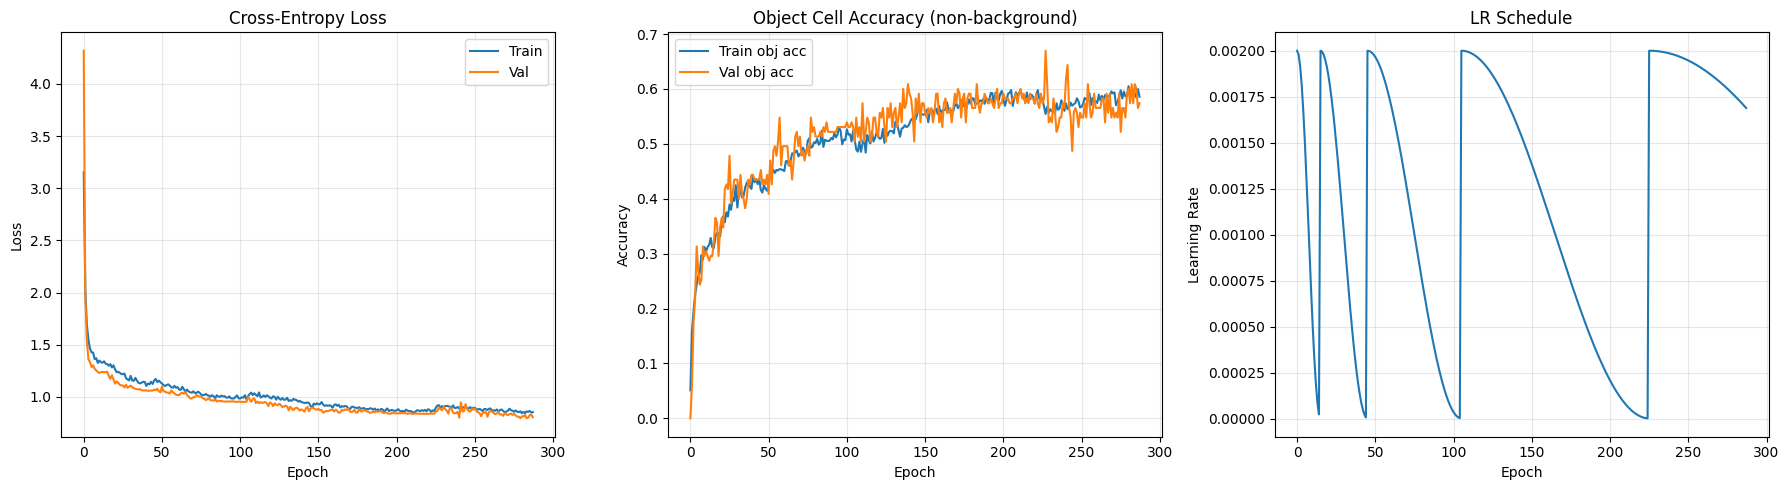

In [70]:
# ── Plot training curves ─────────────────────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Loss
axes[0].plot(history['train_loss'], label='Train')
axes[0].plot(history['val_loss'], label='Val')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Cross-Entropy Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Object accuracy
axes[1].plot(history['train_obj_acc'], label='Train obj acc')
axes[1].plot(history['val_obj_acc'], label='Val obj acc')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Object Cell Accuracy (non-background)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Learning rate
axes[2].plot(history['lr'])
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('Learning Rate')
axes[2].set_title('LR Schedule')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'training_curves.png', dpi=150)
plt.show()

## 8. Evaluation & Visualization

In [71]:
# ── Load best model and visualize predictions ────────────────────────────

checkpoint = torch.load(OUTPUT_DIR / 'fomo_best.pth', map_location=DEVICE)
model.load_state_dict(checkpoint['model_state_dict'])
print(f'Loaded best model from epoch {checkpoint["epoch"]}')
print(f'Val loss: {checkpoint["val_loss"]:.4f}')
print(f'Val object accuracy: {checkpoint["val_obj_acc"]:.3f}')
print('\nPer-class metrics:')
for cls_name, m in checkpoint['class_metrics'].items():
    print(f'  {cls_name:15s}: P={m["precision"]:.3f}  R={m["recall"]:.3f}  F1={m["f1"]:.3f}')

Loaded best model from epoch 280
Val loss: 0.7950
Val object accuracy: 0.591

Per-class metrics:
  sports_ball    : P=0.480  R=0.617  F1=0.540


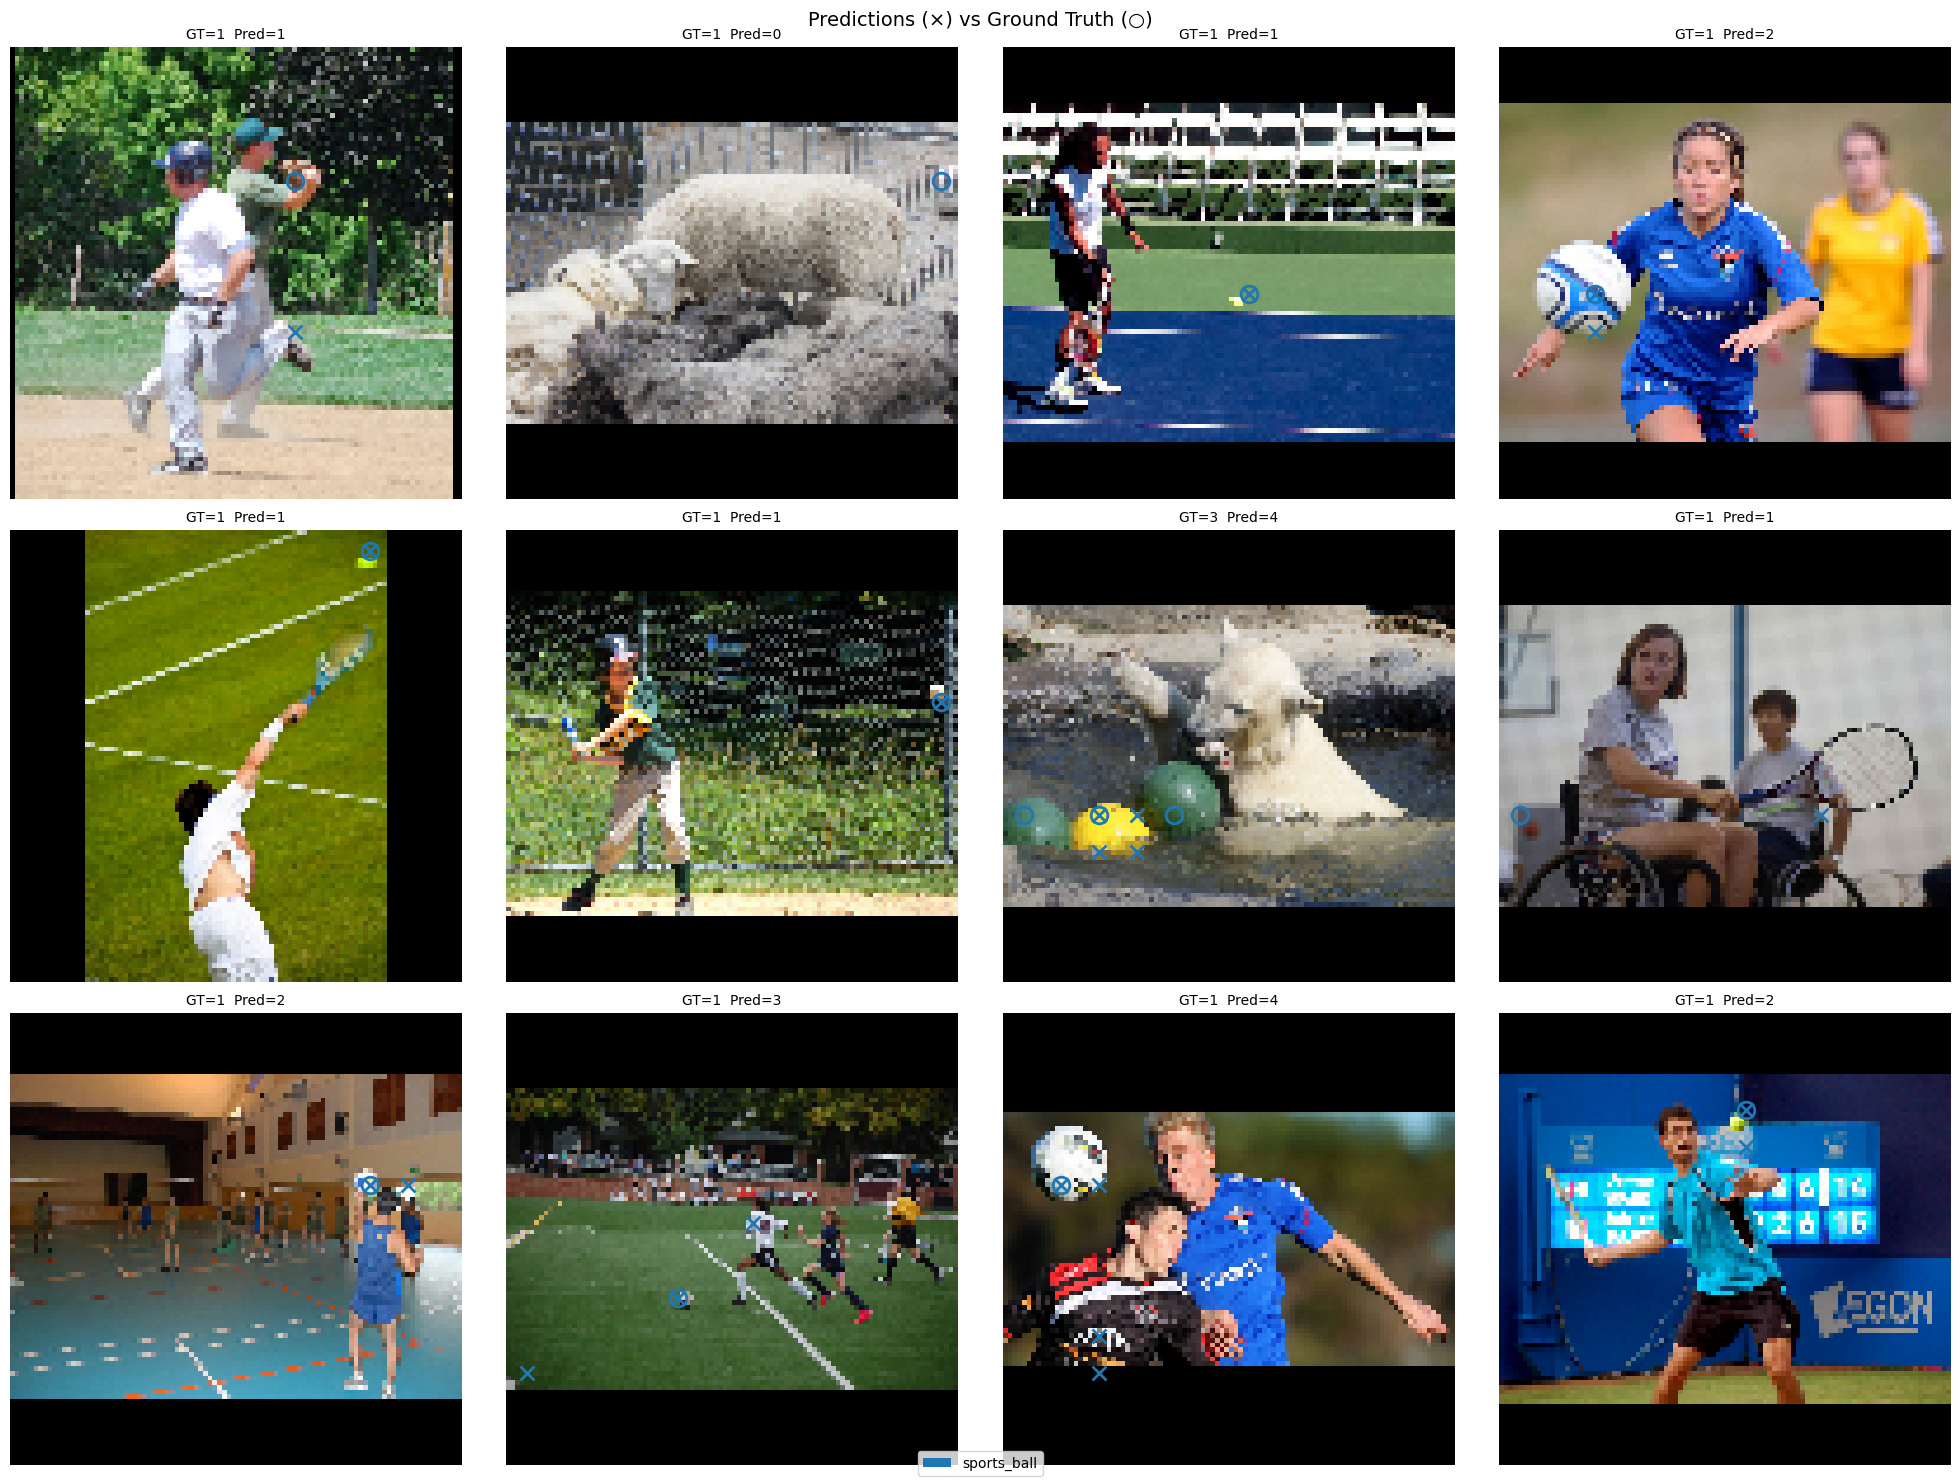

In [72]:
# ── Visualize predictions on validation set ──────────────────────────────

model.eval()
fig, axes = plt.subplots(3, 4, figsize=(20, 15))

for i, ax in enumerate(axes.flat):
    img, heatmaps, targets = val_dataset[i]
    img_tensor = img.unsqueeze(0).to(DEVICE)

    # Get predictions
    detections = model.predict(img_tensor, conf_threshold=CONF_THRESHOLD)[0]

    # Display
    img_display = denormalize(img).permute(1, 2, 0).numpy().squeeze()
    if IS_GRAYSCALE:
        ax.imshow(img_display, cmap='gray')
    else:
        ax.imshow(img_display)
        
    # Draw ground truth (circles)
    for gy in range(GRID_SIZE):
        for gx in range(GRID_SIZE):
            cls = targets[gy, gx].item()
            if cls > 0:
                px = (gx + 0.5) * CELL_SIZE
                py = (gy + 0.5) * CELL_SIZE
                ax.plot(px, py, 'o', color=CLASS_COLORS[cls], markersize=12,
                        markeredgewidth=2, fillstyle='none', label='GT')

    # Draw predictions (crosses)
    for cls, gx, gy, conf in detections:
        px = (gx + 0.5) * CELL_SIZE
        py = (gy + 0.5) * CELL_SIZE
        ax.plot(px, py, 'x', color=CLASS_COLORS[cls], markersize=10, markeredgewidth=2)
        ax.text(px + 3, py - 3, '', #f'{FOMO_CLASS_NAMES[cls]} {conf:.0%} {weight_masks[gx,gy]}',
                fontsize=12, color='white',
                bbox=dict(facecolor=CLASS_COLORS[cls], alpha=0.7, pad=1))

    n_gt = np.count_nonzero(targets)
    n_pred = len(detections)
    ax.set_title(f'GT={n_gt}  Pred={n_pred}', fontsize=10)
    ax.axis('off')

# Legend
legend_elements = [
    mpatches.Patch(facecolor=c, label=FOMO_CLASS_NAMES[i])
    for i, c in CLASS_COLORS.items()
]
fig.legend(handles=legend_elements, loc='lower center', ncol=5, fontsize=10)

plt.suptitle('Predictions (×) vs Ground Truth (○)', fontsize=14)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'val_predictions.png', dpi=150)
plt.show()

## 9. Export to TFLite (Int8 Quantized)

The export pipeline:
1. **PyTorch → ONNX** — standard export
2. **ONNX → TFLite** — using `onnx2tf`
3. **Quantization** — int8 weights + activations using representative dataset
4. **Validate model** - view model dimensions and size

Target: model file < 250 KB for ESP32 flash.

# Step 1: Export to ONNX

model.eval()
model_cpu = model.to('cpu')

dummy_input = torch.randn(1, 1 if IS_GRAYSCALE else 3, INPUT_SIZE, INPUT_SIZE)
onnx_path = OUTPUT_DIR / 'fomo_model.onnx'

torch.onnx.export(
    model_cpu,
    dummy_input,
    str(onnx_path),
    opset_version=18,
    input_names=['input'],
    output_names=['output'],
    dynamic_axes=None,  # Fixed batch size of 1 for MCU
)

onnx_size = onnx_path.stat().st_size / 1024
print(f'ONNX model saved: {onnx_path} ({onnx_size:.1f} KB)')

In [ ]:
# Step 2: ONNX → TFLite with onnx2tf
# pip install onnx2tf tensorflow
import onnx2tf

tf_path = OUTPUT_DIR / "output_tf"
onnx2tf.convert(
    input_onnx_file_path=onnx_path,
    output_folder_path=tf_path,
    non_verbose=True,
)
# This produces a SavedModel in output_tf/

In [ ]:
# Step 3: Quantize with TFLite converter
import tensorflow as tf
import numpy as np

tflite_path = tf_path/"fomo_int8.tflite"
converter = tf.lite.TFLiteConverter.from_saved_model(str(tf_path))
converter.optimizations = [tf.lite.Optimize.DEFAULT]

def representative_dataset():
    for i in range(100):
        img, _ = val_dataset[i]
        # Must be numpy float32 in NHWC format after onnx2tf conversion
        img_np = img.unsqueeze(0).numpy()
        # Transpose NCHW -> NHWC if onnx2tf outputs NHWC signature
        img_np = np.transpose(img_np, (0, 2, 3, 1))
        yield [img_np]

converter.representative_dataset = representative_dataset
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter.inference_input_type = tf.int8
converter.inference_output_type = tf.int8

tflite_model = converter.convert()
with open(tflite_path, "wb") as f:
    f.write(tflite_model)

In [ ]:
# Step 4: Verify the TFLite model

import tensorflow as tf

interpreter = tf.lite.Interpreter(model_path=str(tflite_path))
interpreter.allocate_tensors()

input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

print('Input details:')
for d in input_details:
    print(f'  shape={d["shape"]}  dtype={d["dtype"]}  '
          f'quant={d.get("quantization_parameters", {})}')

print('\nOutput details:')
for d in output_details:
    print(f'  shape={d["shape"]}  dtype={d["dtype"]}  '
          f'quant={d.get("quantization_parameters", {})}')

# Report size
tflite_size = tflite_path.stat().st_size / 1024
print(f'\nTFLite model size: {tflite_size:.1f} KB')
if tflite_size < 250:
    print('✓ Fits in ESP32 flash budget (<250 KB)')
else:
    print('⚠ Model exceeds 250 KB — consider reducing backbone_cutoff or channels')

In [ ]:
# ── Test TFLite model accuracy ───────────────────────────────────────────

def run_tflite_inference(interpreter, image_np):
    """Run one inference on the TFLite model."""
    input_details = interpreter.get_input_details()[0]
    output_details = interpreter.get_output_details()[0]

    # Quantize input if needed
    if input_details['dtype'] == np.int8:
        quant = input_details['quantization_parameters']
        scale = quant['scales'][0]
        zero_point = quant['zero_points'][0]
        image_quantized = (image_np / scale + zero_point).astype(np.int8)
        interpreter.set_tensor(input_details['index'], image_quantized)
    else:
        interpreter.set_tensor(input_details['index'], image_np.astype(np.float32))

    interpreter.invoke()
    output = interpreter.get_tensor(output_details['index'])

    # Dequantize output if needed
    if output_details['dtype'] == np.int8:
        quant = output_details['quantization_parameters']
        scale = quant['scales'][0]
        zero_point = quant['zero_points'][0]
        output = (output.astype(np.float32) - zero_point) * scale

    return output


# Compare PyTorch vs TFLite on 50 validation samples
model_cpu.eval()
match_count = 0
total_cells = 0

for i in range(50):
    img, target = val_dataset[i]
    img_np = img.unsqueeze(0).numpy()
    img_np = img_np.transpose((0,2,3,1)) # NCHW -> NHWC

    # PyTorch prediction
    with torch.no_grad():
        pt_logits = model_cpu(img.unsqueeze(0))
        pt_pred = pt_logits.argmax(dim=1).squeeze().numpy()

    # TFLite prediction
    tfl_logits = run_tflite_inference(interpreter, img_np)
    # Output may be [1, 6, 12, 12] or [1, 12, 12, 6] depending on converter
    if tfl_logits.shape[-1] == NUM_CLASSES:  # NHWC format
        tfl_pred = tfl_logits[0].argmax(axis=-1)
    else:  # NCHW format
        tfl_pred = tfl_logits[0].argmax(axis=0)

    match_count += (pt_pred == tfl_pred).sum()
    total_cells += pt_pred.size

agreement = match_count / total_cells
print(f'PyTorch ↔ TFLite agreement: {agreement:.1%}')

## 10. Convert TFLite to C Header for ESP32

The final step: convert the `.tflite` file to a C byte array that
can be included in the ESP32 firmware.

This generates `fomo_model.h` which the Rust code includes via `include_bytes!()`.

In [ ]:
# ── Generate the model as a raw .tflite binary ───────────────────────────
# The Rust side will use include_bytes!() directly on the .tflite file.
# We also generate a C header as a fallback for C/C++ builds.

import shutil

# Copy the tflite model to the esp32 project directory
esp_model_dir = Path('esp32/model')
esp_model_dir.mkdir(parents=True, exist_ok=True)

dest = esp_model_dir / 'fomo_model_int8.tflite'
shutil.copy2(tflite_path, dest)

# Save model metadata
metadata = {
    'input_size': INPUT_SIZE,
    'grid_size': GRID_SIZE,
    'num_classes': NUM_CLASSES,
    'class_names': FOMO_CLASS_NAMES,
    'normalization': {
        'mean': [0.485, 0.456, 0.406],
        'std': [0.229, 0.224, 0.225],
    },
    'model_size_bytes': len(tflite_model),
}
with open(esp_model_dir / 'model_metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)

print('All export artifacts ready for ESP32!')
print(f'  {dest}')
print(f'  {esp_model_dir / "model_metadata.json"}')